# 07 · Análisis contrafactual — ¿Qué hubiera pasado sin el subsidio del 50%?
**Proyecto ML — Bizkaibus 2026**

**Pregunta**: Si el subsidio del 50% (septiembre 2022) no hubiera existido,  
¿cómo habría evolucionado el número de viajeros de 2022 a 2025?

**Metodología**:
1. Entrenar Prophet **solo con datos pre-subsidio** (enero 2020 – agosto 2022)
2. Proyectar esa tendencia hasta diciembre 2025
3. Comparar proyección vs datos reales
4. La diferencia = **efecto estimado del subsidio**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df_all = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])
pre = pd.read_csv('../data/pre_subsidio.csv', parse_dates=['fecha'])

lineas = sorted(df_all['linea'].unique())
print(f"Datos pre-subsidio: {pre['fecha'].min().date()} → {pre['fecha'].max().date()}")
print(f"Filas: {len(pre)} | Líneas: {pre['linea'].nunique()}")


c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Datos pre-subsidio: 2020-01-01 → 2022-08-01
Filas: 3052 | Líneas: 96


In [2]:
# Análisis contrafactual a nivel agregado (total Bizkaibus)
# para mayor robustez estadística

global_pre = pre.groupby('fecha')['viajeros_total'].sum().reset_index()
global_pre.columns = ['ds', 'y']
global_pre['flag_covid'] = (global_pre['ds'] < '2022-01-01').astype(int)

# Entrenar Prophet solo con datos pre-subsidio
model_cf = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # más conservador: menos overfitting
)
model_cf.add_regressor('flag_covid')
model_cf.fit(global_pre)

# Proyectar desde sep 2022 hasta dic 2025 (40 meses)
n_meses_proyeccion = 40
future_cf = pd.DataFrame({
    'ds': pd.date_range('2022-09-01', periods=n_meses_proyeccion, freq='MS'),
    'flag_covid': 0
})
forecast_cf = model_cf.predict(future_cf)

print(f"Proyección generada: {forecast_cf['ds'].min().date()} → {forecast_cf['ds'].max().date()}")


17:24:37 - cmdstanpy - INFO - Chain [1] start processing
17:24:37 - cmdstanpy - INFO - Chain [1] done processing


Proyección generada: 2022-09-01 → 2025-12-01


In [3]:
# Datos reales post-subsidio
global_post = df_all[df_all['fecha'] >= '2022-09-01'].groupby('fecha')['viajeros_total'].sum().reset_index()
global_post.columns = ['fecha', 'viajeros_real']

# Merge proyección vs real
comparativa = global_post.merge(
    forecast_cf[['ds','yhat','yhat_lower','yhat_upper']].rename(columns={'ds':'fecha'}),
    on='fecha', how='inner'
)
comparativa['viajeros_sin_subsidio'] = comparativa['yhat'].clip(lower=0)
comparativa['efecto_subsidio']        = comparativa['viajeros_real'] - comparativa['viajeros_sin_subsidio']
comparativa['efecto_pct']             = comparativa['efecto_subsidio'] / comparativa['viajeros_sin_subsidio'] * 100

print("=== Efecto del subsidio (promedio mensual) ===")
print(f"  Viajeros reales (media mensual):          {comparativa['viajeros_real'].mean()/1e3:.1f}K")
print(f"  Proyección sin subsidio (media mensual):  {comparativa['viajeros_sin_subsidio'].mean()/1e3:.1f}K")
print(f"  Efecto subsidio (media mensual):          +{comparativa['efecto_subsidio'].mean()/1e3:.1f}K viajeros")
print(f"  Efecto % promedio:                        +{comparativa['efecto_pct'].mean():.1f}%")
print()
total_real = comparativa['viajeros_real'].sum()
total_cf   = comparativa['viajeros_sin_subsidio'].sum()
print(f"  Total acumulado real (sep22–dic25):       {total_real/1e6:.2f}M")
print(f"  Total acumulado sin subsidio:             {total_cf/1e6:.2f}M")
print(f"  Viajeros adicionales por el subsidio:     +{(total_real-total_cf)/1e6:.2f}M (+{(total_real-total_cf)/total_cf*100:.1f}%)")


=== Efecto del subsidio (promedio mensual) ===
  Viajeros reales (media mensual):          2484.5K
  Proyección sin subsidio (media mensual):  2841.6K
  Efecto subsidio (media mensual):          +-357.1K viajeros
  Efecto % promedio:                        +11.3%

  Total acumulado real (sep22–dic25):       99.38M
  Total acumulado sin subsidio:             113.66M
  Viajeros adicionales por el subsidio:     +-14.28M (+-12.6%)


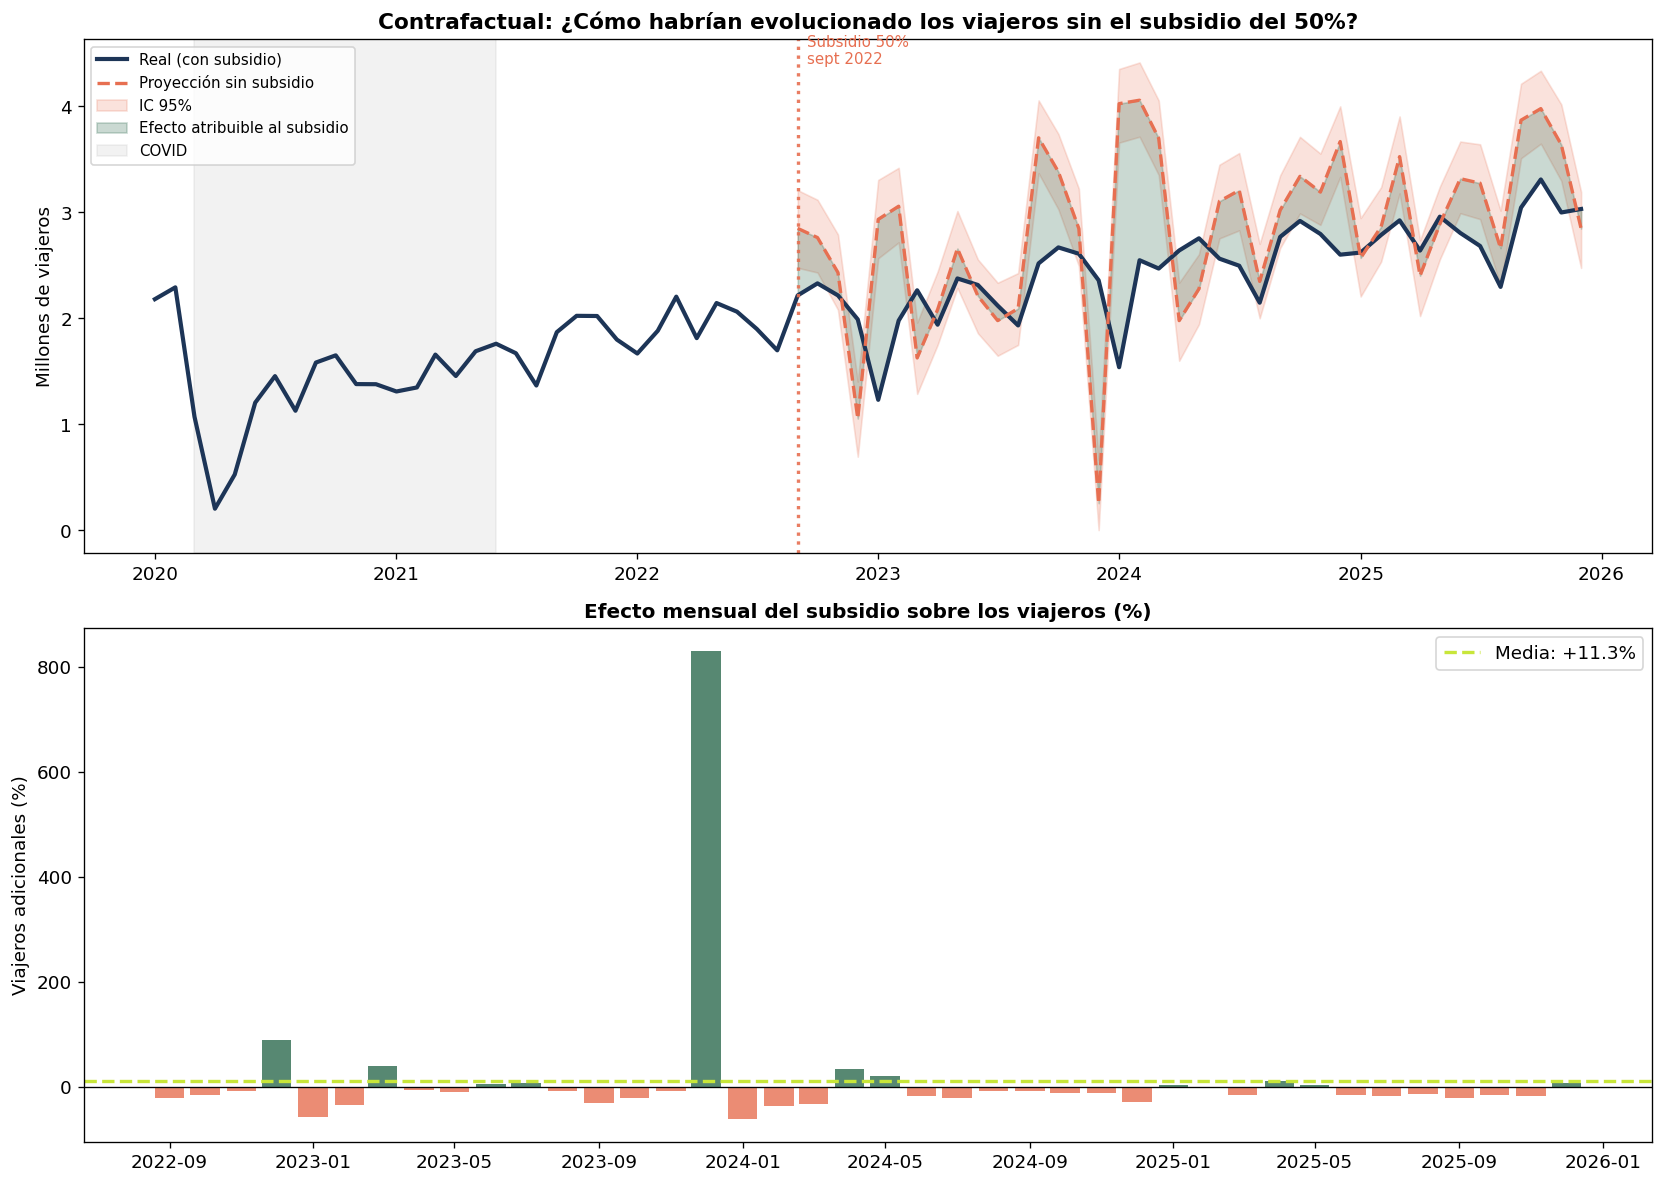

In [4]:
# Gráfico principal del contrafactual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Panel 1: real vs contrafactual
ax = axes[0]
global_all = df_all.groupby('fecha')['viajeros_total'].sum().reset_index()

ax.plot(global_all['fecha'], global_all['viajeros_total']/1e6,
        color='#1d3557', linewidth=2.5, label='Real (con subsidio)')
ax.plot(comparativa['fecha'], comparativa['viajeros_sin_subsidio']/1e6,
        color='#e76f51', linewidth=2, linestyle='--', label='Proyección sin subsidio')
ax.fill_between(comparativa['fecha'], 
                comparativa['yhat_lower'].clip(lower=0)/1e6,
                comparativa['yhat_upper'].clip(lower=0)/1e6,
                alpha=0.2, color='#e76f51', label='IC 95%')
ax.fill_between(comparativa['fecha'],
                comparativa['viajeros_sin_subsidio']/1e6,
                comparativa['viajeros_real']/1e6,
                alpha=0.25, color='#2d6a4f', label='Efecto atribuible al subsidio')
ax.axvline(pd.Timestamp('2022-09-01'), color='#e76f51', linewidth=2, linestyle=':', alpha=0.9)
ax.text(pd.Timestamp('2022-09-15'), ax.get_ylim()[1]*0.95, 'Subsidio 50%\nsept 2022',
        color='#e76f51', fontsize=9)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), 
           alpha=0.1, color='gray', label='COVID')
ax.set_title('Contrafactual: ¿Cómo habrían evolucionado los viajeros sin el subsidio del 50%?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Millones de viajeros')
ax.legend(loc='upper left', fontsize=9)

# ── Panel 2: efecto mensual en %
ax2 = axes[1]
colors_ef = ['#2d6a4f' if v > 0 else '#e76f51' for v in comparativa['efecto_pct']]
ax2.bar(comparativa['fecha'], comparativa['efecto_pct'], color=colors_ef, width=25, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(comparativa['efecto_pct'].mean(), color='#c8e63a', linewidth=2,
            linestyle='--', label=f"Media: +{comparativa['efecto_pct'].mean():.1f}%")
ax2.set_title('Efecto mensual del subsidio sobre los viajeros (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Viajeros adicionales (%)')
ax2.legend()

plt.tight_layout()
plt.show()


In [5]:
# Guardar resultado del contrafactual
comparativa.to_csv('../data/contrafactual_subsidio.csv', index=False)
print("✓ contrafactual_subsidio.csv guardado")

# Contexto con H4 del EDA original
print()
print("=== Conexión con hipótesis H4 del EDA ===")
print(f"  H4 original (EDA):  +54.8% de crecimiento post-subsidio")
efecto_medio = comparativa['efecto_pct'].mean()
print(f"  Contrafactual ML:   +{efecto_medio:.1f}% de efecto estimado del subsidio")
print()
print("  → El modelo ML permite cuantificar el efecto PURO del subsidio,")
print("    descontando la tendencia natural de recuperación post-COVID.")

# Análisis por año
print()
comparativa['año'] = pd.to_datetime(comparativa['fecha']).dt.year
ef_anual = comparativa.groupby('año')['efecto_pct'].mean()
print("Efecto del subsidio por año:")
print(ef_anual.round(1).to_string())


✓ contrafactual_subsidio.csv guardado

=== Conexión con hipótesis H4 del EDA ===
  H4 original (EDA):  +54.8% de crecimiento post-subsidio
  Contrafactual ML:   +11.3% de efecto estimado del subsidio

  → El modelo ML permite cuantificar el efecto PURO del subsidio,
    descontando la tendencia natural de recuperación post-COVID.

Efecto del subsidio por año:
año
2022    10.5
2023    58.3
2024   -15.7
2025    -8.5


17:24:37 - cmdstanpy - INFO - Chain [1] start processing
17:24:37 - cmdstanpy - INFO - Chain [1] done processing
17:24:37 - cmdstanpy - INFO - Chain [1] start processing
17:24:38 - cmdstanpy - INFO - Chain [1] done processing
17:24:38 - cmdstanpy - INFO - Chain [1] start processing
17:24:38 - cmdstanpy - INFO - Chain [1] done processing
17:24:38 - cmdstanpy - INFO - Chain [1] start processing
17:24:38 - cmdstanpy - INFO - Chain [1] done processing
17:24:38 - cmdstanpy - INFO - Chain [1] start processing
17:24:38 - cmdstanpy - INFO - Chain [1] done processing
17:24:38 - cmdstanpy - INFO - Chain [1] start processing
17:24:39 - cmdstanpy - INFO - Chain [1] done processing
17:24:39 - cmdstanpy - INFO - Chain [1] start processing
17:24:39 - cmdstanpy - INFO - Chain [1] done processing
17:24:39 - cmdstanpy - INFO - Chain [1] start processing
17:24:39 - cmdstanpy - INFO - Chain [1] done processing
17:24:39 - cmdstanpy - INFO - Chain [1] start processing
17:24:39 - cmdstanpy - INFO - Chain [1]

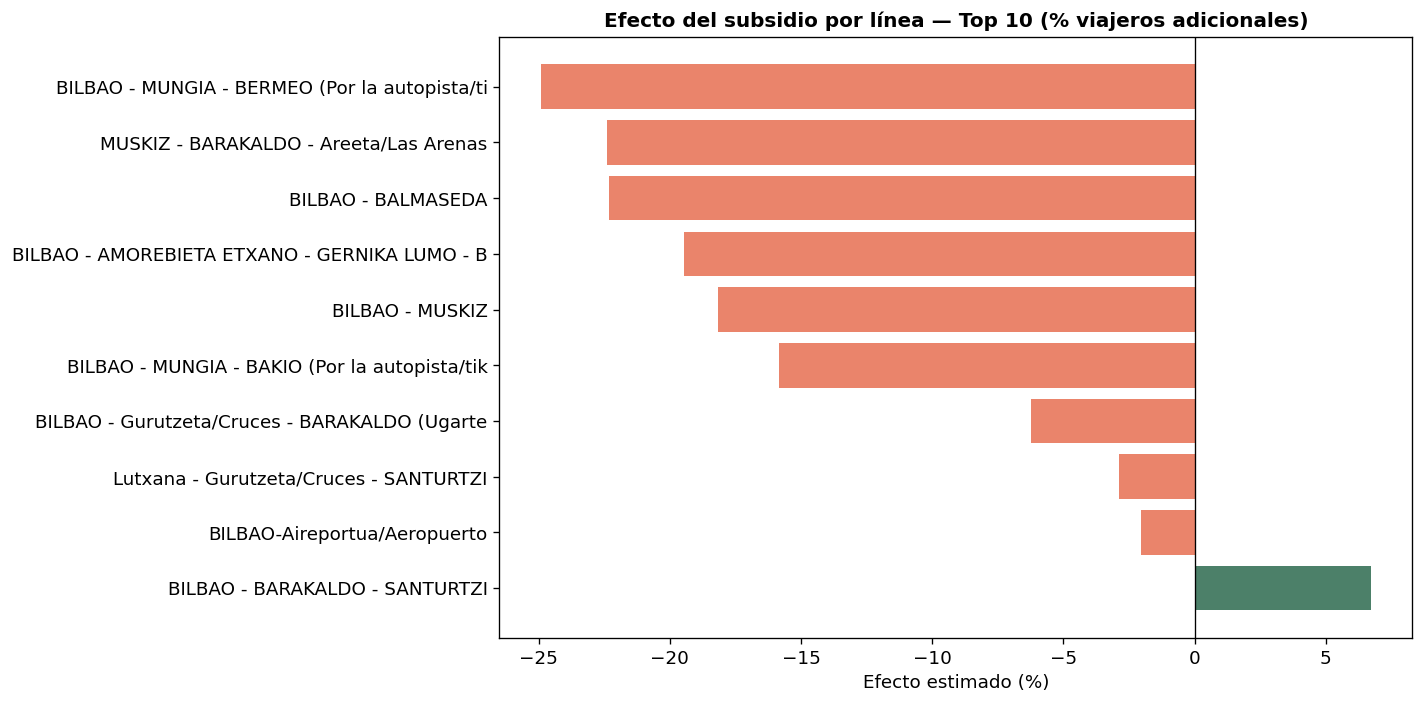

                                        linea  efecto_viajeros  efecto_pct
               BILBAO - BARAKALDO - SANTURTZI       301.022576    6.721113
                 BILBAO-Aireportua/Aeropuerto       -90.754159   -2.042478
       Lutxana - Gurutzeta/Cruces - SANTURTZI      -131.127859   -2.863554
BILBAO - Gurutzeta/Cruces - BARAKALDO (Ugarte      -160.125909   -6.234785
BILBAO - MUNGIA - BAKIO (Por la autopista/tik      -451.061314  -15.835929
                              BILBAO - MUSKIZ      -699.017367  -18.160138
BILBAO - AMOREBIETA ETXANO - GERNIKA LUMO - B      -814.681327  -19.474972
                           BILBAO - BALMASEDA      -863.209047  -22.315909
       MUSKIZ - BARAKALDO - Areeta/Las Arenas      -689.401242  -22.377806
BILBAO - MUNGIA - BERMEO (Por la autopista/ti     -1093.401446  -24.917580


In [6]:
# Análisis contrafactual por línea (Top 10)
top10_lineas = df_all.groupby('linea')['viajeros_total'].sum().sort_values(ascending=False).head(10).index.tolist()

resultados_cf_linea = []

for linea in top10_lineas:
    serie_pre = pre[pre['linea'] == linea].sort_values('fecha')[['fecha','viajeros_total']].copy()
    serie_pre.columns = ['ds','y']
    serie_pre['flag_covid'] = (serie_pre['ds'] < '2022-01-01').astype(int)
    
    if len(serie_pre) < 15:
        continue
    
    try:
        m = Prophet(seasonality_mode='multiplicative', changepoint_prior_scale=0.05,
                    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        m.add_regressor('flag_covid')
        m.fit(serie_pre)
        
        fut = pd.DataFrame({'ds': pd.date_range('2022-09-01', periods=40, freq='MS'), 'flag_covid': 0})
        fc  = m.predict(fut)
        
        real_linea = df_all[(df_all['linea']==linea) & (df_all['fecha']>='2022-09-01')].copy()
        real_linea = real_linea.merge(fc[['ds','yhat']].rename(columns={'ds':'fecha'}), on='fecha', how='inner')
        
        if len(real_linea) > 0:
            efecto = (real_linea['viajeros_total'].sum() - real_linea['yhat'].clip(lower=0).sum())
            efecto_pct = efecto / real_linea['yhat'].clip(lower=0).sum() * 100
            resultados_cf_linea.append({'linea': linea[:45], 'efecto_viajeros': efecto/1e3, 'efecto_pct': efecto_pct})
    except:
        pass

cf_linea_df = pd.DataFrame(resultados_cf_linea).sort_values('efecto_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2d6a4f' if v > 0 else '#e76f51' for v in cf_linea_df['efecto_pct']]
ax.barh(cf_linea_df['linea'], cf_linea_df['efecto_pct'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Efecto del subsidio por línea — Top 10 (% viajeros adicionales)', fontsize=12, fontweight='bold')
ax.set_xlabel('Efecto estimado (%)')
plt.tight_layout()
plt.show()
print(cf_linea_df.to_string(index=False))
